<a href="https://colab.research.google.com/github/llayan-1/typiclust-cw2/blob/main/typiclust_cw2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Coursework 2

**Name:** Layan Alsubhi

**Student Number:** K23065725

**Module:** 5CCSAMLF Machine Learning

In [19]:
import random
import math
import numpy as np
from collections import defaultdict

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

import torchvision
import torchvision.transforms as transforms
import torchvision.models as models

from torch.utils.data import Dataset, DataLoader, Subset

from sklearn.cluster import MiniBatchKMeans
from sklearn.neighbors import NearestNeighbors
from sklearn.cluster import KMeans, MiniBatchKMeans

import matplotlib.pyplot as plt

In [20]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

Device: cuda


In [21]:
CIFAR10_MEAN = (0.4914, 0.4822, 0.4465)
CIFAR10_STD = (0.2023, 0.1994, 0.2010)

In [22]:
simclr_transform = transforms.Compose([
    transforms.RandomResizedCrop(size=32, scale=(0.2, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomApply([
        transforms.ColorJitter(0.4, 0.4, 0.4, 0.1)
    ], p=0.8),
    transforms.RandomGrayscale(p=0.2),
    transforms.ToTensor(),
    transforms.Normalize(CIFAR10_MEAN, CIFAR10_STD)
])

test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(CIFAR10_MEAN, CIFAR10_STD)
])

In [23]:
class SimCLRDataset(Dataset):
    def __init__(self, base_dataset, transform):
        self.base_dataset = base_dataset
        self.transform = transform

    def __len__(self):
        return len(self.base_dataset)

    def __getitem__(self, idx):
        image, _ = self.base_dataset[idx]
        view1 = self.transform(image)
        view2 = self.transform(image)
        return view1, view2, idx

In [24]:
# Raw training dataset
train_base = torchvision.datasets.CIFAR10(
    root="./data",
    train=True,
    download=True,
    transform=None
)

# Test set for final supervised evaluation
test_set = torchvision.datasets.CIFAR10(
    root="./data",
    train=False,
    download=True,
    transform=test_transform
)

# Single-view normalised train set for evaluation classifier
train_eval_set = torchvision.datasets.CIFAR10(
    root="./data",
    train=True,
    download=False,
    transform=test_transform
)

print("Train size:", len(train_base))
print("Test size:", len(test_set))

Train size: 50000
Test size: 10000


In [25]:
simclr_dataset = SimCLRDataset(train_base, simclr_transform)

simclr_loader = DataLoader(
    simclr_dataset,
    batch_size=512,
    shuffle=True,
    num_workers=2,
    drop_last=True
)

print("SimCLR batches:", len(simclr_loader))

SimCLR batches: 97


In [26]:
class ResNet18Encoder(nn.Module):
    def __init__(self):
        super().__init__()
        backbone = models.resnet18(weights=None)

        # CIFAR adaptation
        backbone.conv1 = nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False)
        backbone.maxpool = nn.Identity()

        self.features = nn.Sequential(*list(backbone.children())[:-1])
        self.feature_dim = backbone.fc.in_features

    def forward(self, x):
        x = self.features(x)
        x = torch.flatten(x, 1)
        return x

In [27]:
class SimCLRModel(nn.Module):
    def __init__(self, projection_dim=128):
        super().__init__()
        self.encoder = ResNet18Encoder()
        self.projector = nn.Sequential(
            nn.Linear(self.encoder.feature_dim, 512),
            nn.ReLU(inplace=True),
            nn.Linear(512, projection_dim)
        )

    def forward(self, x):
        features = self.encoder(x)
        projections = self.projector(features)
        projections = F.normalize(projections, dim=1)
        return features, projections

In [28]:
class NTXentLoss(nn.Module):
    def __init__(self, temperature=0.5):
        super().__init__()
        self.temperature = temperature

    def forward(self, z1, z2):
        batch_size = z1.size(0)

        z = torch.cat([z1, z2], dim=0)
        sim = torch.matmul(z, z.T) / self.temperature

        mask = torch.eye(2 * batch_size, device=z.device, dtype=torch.bool)
        sim.masked_fill_(mask, -9e15)



        labels = torch.cat([torch.arange(batch_size, 2 * batch_size, device=z.device),
            torch.arange(0, batch_size, device=z.device)])
        logits = sim

        # denominator includes all except self
        loss = F.cross_entropy(sim, labels)
        return loss

In [29]:
def train_simclr(model, loader, epochs=50, lr=0.4):
    criterion = NTXentLoss(temperature=0.5)
    optimizer = optim.SGD(
        model.parameters(),
        lr=lr,
        momentum=0.9,
        weight_decay=1e-4,
        nesterov=True
    )
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)

    model.train()

    for epoch in range(epochs):
        running_loss = 0.0

        for x1, x2, _ in loader:
            x1 = x1.to(device)
            x2 = x2.to(device)

            _, z1 = model(x1)
            _, z2 = model(x2)

            loss = criterion(z1, z2)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            running_loss += loss.item()

        scheduler.step()
        avg_loss = running_loss / len(loader)
        print(f"SimCLR Epoch {epoch + 1}/{epochs}, Loss: {avg_loss:.4f}")

In [30]:
simclr_model = SimCLRModel(projection_dim=128).to(device)
train_simclr(simclr_model, simclr_loader, epochs=50, lr=0.4)

SimCLR Epoch 1/50, Loss: 6.2717
SimCLR Epoch 2/50, Loss: 5.8970
SimCLR Epoch 3/50, Loss: 5.7696
SimCLR Epoch 4/50, Loss: 5.6899
SimCLR Epoch 5/50, Loss: 5.6210
SimCLR Epoch 6/50, Loss: 5.5650
SimCLR Epoch 7/50, Loss: 5.5257
SimCLR Epoch 8/50, Loss: 5.4967
SimCLR Epoch 9/50, Loss: 5.4702
SimCLR Epoch 10/50, Loss: 5.4524
SimCLR Epoch 11/50, Loss: 5.4348
SimCLR Epoch 12/50, Loss: 5.4192
SimCLR Epoch 13/50, Loss: 5.4107
SimCLR Epoch 14/50, Loss: 5.4003
SimCLR Epoch 15/50, Loss: 5.3916
SimCLR Epoch 16/50, Loss: 5.3849
SimCLR Epoch 17/50, Loss: 5.3764
SimCLR Epoch 18/50, Loss: 5.3673
SimCLR Epoch 19/50, Loss: 5.3598
SimCLR Epoch 20/50, Loss: 5.3564
SimCLR Epoch 21/50, Loss: 5.3512
SimCLR Epoch 22/50, Loss: 5.3460
SimCLR Epoch 23/50, Loss: 5.3438
SimCLR Epoch 24/50, Loss: 5.3360
SimCLR Epoch 25/50, Loss: 5.3302
SimCLR Epoch 26/50, Loss: 5.3244
SimCLR Epoch 27/50, Loss: 5.3228
SimCLR Epoch 28/50, Loss: 5.3173
SimCLR Epoch 29/50, Loss: 5.3130
SimCLR Epoch 30/50, Loss: 5.3084
SimCLR Epoch 31/50,

In [31]:
feature_loader = DataLoader(
    train_eval_set,
    batch_size=256,
    shuffle=False,
    num_workers=2
)

In [32]:
def extract_all_embeddings(encoder_model, loader):
    encoder_model.eval()
    all_embeddings = []

    with torch.no_grad():
        for images, _ in loader:
            images = images.to(device)
            embeddings = F.normalize(encoder_model.encoder(images), dim=1)
            all_embeddings.append(embeddings.cpu())

    all_embeddings = torch.cat(all_embeddings, dim=0)
    return all_embeddings.numpy()

all_train_embeddings = extract_all_embeddings(simclr_model, feature_loader)
print("All train embeddings shape:", all_train_embeddings.shape)

All train embeddings shape: (50000, 512)


In [33]:
def train_eval_model(model, loader, epochs=50, lr=0.025):
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.SGD(
        model.parameters(),
        lr=lr,
        momentum=0.9,
        nesterov=True,
        weight_decay=5e-4)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)

    model.train()

    for epoch in range(epochs):
        running_loss = 0.0

        for images, labels in loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            running_loss += loss.item()

        scheduler.step()
        avg_loss = running_loss / len(loader)
        print(f"Eval Epoch {epoch + 1}/{epochs}, Loss: {avg_loss:.4f}")

In [34]:
def evaluate_model(model, loader):
    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            preds = outputs.argmax(dim=1)

            total += labels.size(0)
            correct += (preds == labels).sum().item()

    return 100.0 * correct / total

In [35]:
test_loader = DataLoader(
    test_set,
    batch_size=256,
    shuffle=False,
    num_workers=2
)

In [36]:
def compute_typicality_scores(cluster_embeddings, k=20):
    if len(cluster_embeddings) == 1:
        return np.array([1.0], dtype=np.float32)

    k_use = min(k, len(cluster_embeddings) - 1)
    nbrs = NearestNeighbors(n_neighbors=k_use + 1, metric="euclidean")
    nbrs.fit(cluster_embeddings)
    distances, _ = nbrs.kneighbors(cluster_embeddings)
    avg_distances = distances[:, 1:].mean(axis=1)
    typicality_scores = 1.0 / (avg_distances + 1e-8)

    return typicality_scores

In [37]:
def typiclust_select_batch(
    all_embeddings,
    labelled_indices,
    unlabelled_indices,
    budget=10,
    max_clusters=500,
    typicality_k=20
):
    labelled_indices = list(labelled_indices)
    unlabelled_indices = list(unlabelled_indices)

    if len(unlabelled_indices) == 0:
        return []

    # number of clusters
    num_clusters = min(len(labelled_indices) + budget, max_clusters, len(unlabelled_indices))

    unlabelled_embeddings = all_embeddings[unlabelled_indices]

    kmeans = MiniBatchKMeans(
        n_clusters=num_clusters,
        random_state=SEED,
        batch_size=1024,
        n_init=10
    )
    unlabelled_cluster_labels = kmeans.fit_predict(unlabelled_embeddings)

    # assign labelled points to nearest cluster centre
    labelled_cluster_counts = np.zeros(num_clusters, dtype=int)
    if len(labelled_indices) > 0:
        labelled_embeddings = all_embeddings[labelled_indices]
        distances_to_centers = np.linalg.norm(
            labelled_embeddings[:, None, :] - kmeans.cluster_centers_[None, :, :],
            axis=2
        )
        labelled_cluster_ids = distances_to_centers.argmin(axis=1)

        for cid in labelled_cluster_ids:
            labelled_cluster_counts[cid] += 1

    cluster_to_unlabelled_positions = defaultdict(list)
    for pos, cid in enumerate(unlabelled_cluster_labels):
        cluster_to_unlabelled_positions[cid].append(pos)

    # build cluster metadata
    cluster_info = []
    for cid, positions in cluster_to_unlabelled_positions.items():
        if len(positions) >= 5:
            cluster_info.append({
                "cluster_id": cid,
                "labelled_count": labelled_cluster_counts[cid],
                "size": len(positions),
                "positions": positions
            })

    selected_positions = []
    used_clusters = set()

    while len(selected_positions) < budget and len(used_clusters) < len(cluster_info):
        remaining = [c for c in cluster_info if c["cluster_id"] not in used_clusters]
        if not remaining:
            break

        min_labelled = min(c["labelled_count"] for c in remaining)
        candidates = [c for c in remaining if c["labelled_count"] == min_labelled]

        # among fewest-labelled clusters, prefer the largest
        candidates.sort(key=lambda x: x["size"], reverse=True)
        chosen_cluster = candidates[0]

        cid = chosen_cluster["cluster_id"]
        positions = chosen_cluster["positions"]
        cluster_embeddings = unlabelled_embeddings[positions]

        typicality_scores = compute_typicality_scores(cluster_embeddings, k=typicality_k)
        best_local_idx = np.argmax(typicality_scores)
        best_pos = positions[best_local_idx]

        selected_positions.append(best_pos)
        used_clusters.add(cid)


    if len(selected_positions) < budget:
        print(f"Warning: only selected {len(selected_positions)} of {budget} requested.")

    selected_dataset_indices = [unlabelled_indices[pos] for pos in selected_positions]
    return selected_dataset_indices

In [38]:
class EvalResNet18(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        backbone = models.resnet18(weights=None)
        backbone.conv1 = nn.Conv2d(3, 64, kernel_size=3,
                                    stride=1, padding=1, bias=False)
        backbone.maxpool = nn.Identity()
        backbone.fc = nn.Linear(512, num_classes)
        self.model = backbone

    def forward(self, x):
        return self.model(x)


train_transform_supervised = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(CIFAR10_MEAN, CIFAR10_STD),
])


class LabeledSubset(Dataset):
    def __init__(self, indices, transform):
        self.base = torchvision.datasets.CIFAR10(
            root='./data', train=True, download=False, transform=None)
        self.indices = indices
        self.transform = transform

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, i):
        img, label = self.base[self.indices[i]]
        return self.transform(img), label


def active_learning_round_tpcrp(
    all_embeddings,
    labelled_indices,
    unlabelled_indices,
    budget=10,
    eval_batch_size=128,
    eval_epochs=50
):
    # select batch
    newly_selected = typiclust_select_batch(
        all_embeddings=all_embeddings,
        labelled_indices=labelled_indices,
        unlabelled_indices=unlabelled_indices,
        budget=budget,
        max_clusters=500,
        typicality_k=20
    )

    # update pools
    labelled_indices = list(labelled_indices) + newly_selected
    selected_set = set(newly_selected)
    unlabelled_indices = [idx for idx in unlabelled_indices if idx not in selected_set]

    # build labelled subset with training augmentation
    labelled_subset = LabeledSubset(labelled_indices, transform=train_transform_supervised)
    labelled_loader = DataLoader(
        labelled_subset,
        batch_size=eval_batch_size,
        shuffle=True,
        num_workers=2
    )

    # reinitialise evaluation model from scratch each round
    eval_model = EvalResNet18(num_classes=10).to(device)
    train_eval_model(eval_model, labelled_loader, epochs=eval_epochs, lr=0.025)

    accuracy = evaluate_model(eval_model, test_loader)

    return labelled_indices, unlabelled_indices, accuracy

In [39]:
# Cold start: L_0 = empty
labelled_indices_tpcrp = []
unlabelled_indices_tpcrp = list(range(len(train_base)))  # all 50,000 images

all_train_labels = np.array(train_base.targets)

print("Initial labelled  :", len(labelled_indices_tpcrp))
print("Initial unlabelled:", len(unlabelled_indices_tpcrp))

Initial labelled  : 0
Initial unlabelled: 50000


In [40]:
budget_per_round = 10
num_rounds = 5

results = []

for round_num in range(num_rounds):
    print(f"\n===== Round {round_num + 1}/{num_rounds} =====")

    labelled_indices_tpcrp, unlabelled_indices_tpcrp, acc = active_learning_round_tpcrp(
        all_embeddings=all_train_embeddings,
        labelled_indices=labelled_indices_tpcrp,
        unlabelled_indices=unlabelled_indices_tpcrp,
        budget=budget_per_round,
        eval_batch_size=128,
        eval_epochs=50
    )

    class_counts = np.bincount(all_train_labels[labelled_indices_tpcrp], minlength=10)
    print(f"Labelled    : {len(labelled_indices_tpcrp)}")
    print(f"Unlabelled  : {len(unlabelled_indices_tpcrp)}")
    print(f"Class dist  : {class_counts.tolist()}")
    print(f"Test Accuracy: {acc:.2f}%")

    results.append({
        "round": round_num + 1,
        "labelled": len(labelled_indices_tpcrp),
        "accuracy": acc
    })


===== Round 1/5 =====
Eval Epoch 1/50, Loss: 2.2233
Eval Epoch 2/50, Loss: 1.8715
Eval Epoch 3/50, Loss: 1.7121
Eval Epoch 4/50, Loss: 1.8483
Eval Epoch 5/50, Loss: 1.6405
Eval Epoch 6/50, Loss: 1.0288
Eval Epoch 7/50, Loss: 0.8658
Eval Epoch 8/50, Loss: 0.6223
Eval Epoch 9/50, Loss: 0.5130
Eval Epoch 10/50, Loss: 0.5167
Eval Epoch 11/50, Loss: 0.2439
Eval Epoch 12/50, Loss: 0.1357
Eval Epoch 13/50, Loss: 0.4679
Eval Epoch 14/50, Loss: 0.0772
Eval Epoch 15/50, Loss: 0.1177
Eval Epoch 16/50, Loss: 0.0621
Eval Epoch 17/50, Loss: 0.0811
Eval Epoch 18/50, Loss: 0.0365
Eval Epoch 19/50, Loss: 0.0199
Eval Epoch 20/50, Loss: 0.0167
Eval Epoch 21/50, Loss: 0.0193
Eval Epoch 22/50, Loss: 0.0116
Eval Epoch 23/50, Loss: 0.0206
Eval Epoch 24/50, Loss: 0.0140
Eval Epoch 25/50, Loss: 0.0035
Eval Epoch 26/50, Loss: 0.0045
Eval Epoch 27/50, Loss: 0.0023
Eval Epoch 28/50, Loss: 0.0029
Eval Epoch 29/50, Loss: 0.0030
Eval Epoch 30/50, Loss: 0.0025
Eval Epoch 31/50, Loss: 0.0030
Eval Epoch 32/50, Loss: 0

In [41]:
for row in results:
    print(f"Round {row['round']}: labelled={row['labelled']}, accuracy={row['accuracy']:.2f}%")

Round 1: labelled=10, accuracy=14.79%
Round 2: labelled=20, accuracy=19.00%
Round 3: labelled=30, accuracy=21.66%
Round 4: labelled=40, accuracy=24.59%
Round 5: labelled=50, accuracy=26.62%


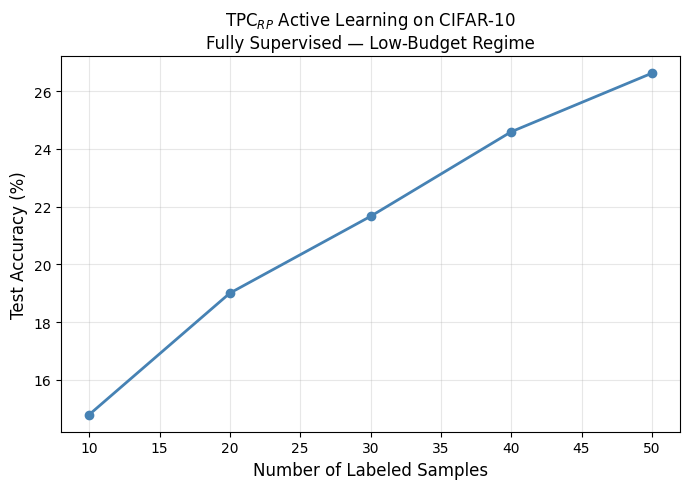

In [43]:
labelled_counts = [r["labelled"] for r in results]
accuracies = [r["accuracy"] for r in results]

plt.figure(figsize=(7, 5))
plt.plot(labelled_counts, accuracies, marker="o", linewidth=2, color="steelblue")
plt.xlabel("Number of Labeled Samples", fontsize=12)
plt.ylabel("Test Accuracy (%)", fontsize=12)
plt.title("TPC$_{RP}$ Active Learning on CIFAR-10\nFully Supervised — Low-Budget Regime", fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("tpcrp_results.png", dpi=150, bbox_inches="tight")
plt.show()

## Code Repository

The full implementation is available at the following GitHub repository:

[GitHub Repository Link](https://github.com/llayan-1/typiclust-cw2.git)